In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time


# Definición de las funciones para obtener la función de costo, su gradiente y su hessiano.

## Función experimento 1

In [2]:
def f_func(x):
    """Función f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 

    Retorna:
    - f(x) : numpy array
    """
    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = np.sum((idx_arr)*(np.exp(x) - x))
    return output


def grad_func(x):
    """Gradiente de f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 
    Retorna:
    - grad_f(x) : numpy array"""

    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = (idx_arr)*(np.exp(x) - 1)
    return output


def hessian_func(x):
    """Hessiana de f(x) = sum _{i=1}^{n} [i/10 * (e^{x_i} - x_i)] (experimento 1 del paper)
    Recibe:
    - x : una lista 
    Retorna:
    - hess_f(x) : numpy array"""

    x = np.array(x, dtype= np.float64)
    n = len(x)
    idx_arr = (np.arange(1, n+1) / 10.0)
    output = idx_arr * np.exp(x)
    return np.diag(output)


def Hk_gk_func(x):
    """Función que devuelve el resultado de Hk*gk
    Recibe:
    - Hk : numpy array con información de la Hessiana
    - gk : numpy array con el gradiente de la función en el punto xk
    Retorna:
    - Hk*gk : numpy array
    """
    Hk = hessian_func(x)
    gk = grad_func(x)
    return Hk*gk



   

## Función experimento 3

In [29]:
def f2_func(x, lambda_val = None):
    """Función f2(x) = - log (lambda^2 - x^T x) (experimento 3 del paper)
    Recibe:
    - x : una lista 
    - lambda_val : un escalar positivo

    Retorna:
    - f2(x) : numpy array
    """
    if lambda_val is None:
        lambda_val = 10.0 * len(x)  # Valor predeterminado de lambda usado en paper

    x = np.array(x, dtype= np.float64)
    dot_p = np.dot(x, x)
    output = - np.log(lambda_val**2 - dot_p)

    return output


def grad2_func(x, lambda_val = None):
    """Gradiente de f2(x) = - log (lambda^2 - x^T x) (experimento 3 del paper)
    Recibe:
    - x : una lista 
    - lambda_val : un escalar positivo

    Retorna:
    - grad_f2(x) : numpy array
    """
    if lambda_val is None:
        lambda_val = 10.0 * len(x)  # Valor predeterminado de lambda usado en paper

    x = np.array(x, dtype= np.float64)
    dot_p = np.dot(x, x)
    output = (2*x) / (lambda_val**2 - dot_p)

    return output

def hessian2_func(x, lambda_val = None):
    """Hessiana de f2(x) = - log (lambda^2 - x^T x) (experimento 3 del paper)
    Recibe:
    - x : una lista 
    - lambda_val : un escalar positivo

    Retorna:
    - hess_f2(x) : numpy array
    """
    if lambda_val is None:
        lambda_val = 10.0 * len(x)  # Valor predeterminado de lambda usado en paper

    x = np.array(x, dtype= np.float64)
    dot_p = np.dot(x, x)
    n = len(x)
    
    # Matriz identidad
    I = np.eye(n)
    
    # Cálculo de la Hessiana
    term1 = (2 / (lambda_val**2 - dot_p)) * I
    term2 = (4 / (lambda_val**2 - dot_p)**2) * np.outer(x, x)
    
    output = term1 + term2
    
    return output

## Experimento 4

In [104]:
def f3_func(x, z, y, sigma):
    """ 
    Función experimento 4,f(x) = (sigma/2)*||x||^2 + sum(log(1 + e^{-(x^T z^i)y^i}))
    """
    x = np.array(x, dtype=np.float64) #n
    z = np.array(z, dtype=np.float64) # mxn
    y = np.array(y, dtype=np.float64) # m x c
    

    dot_products = z @ x 
    loss_vector = np.logaddexp(0, -dot_products * y)
    
    term1 = (sigma / 2) * np.linalg.norm(x)**2
    term2 = np.sum(loss_vector)
    
    return term1 + term2

def grad3_func(x, z, y, sigma):
    """ 
    Gradiente de la función del experimento 4
    """
    x = np.array(x, dtype=np.float64) 
    z = np.array(z, dtype=np.float64) 
    y = np.array(y, dtype=np.float64) 

    # (x^T z^i) * y^i 
    v = (z @ x) * y
    
    weights = y / (1 + np.exp(v))
    
    # sum(weights_i * z^i) 
    gradient = sigma * x - (z.T @ weights)
    
    return gradient


def hessian3_func(x, z, y, sigma):
    """
    Hessiano para la función del experimento 4.
    Retorna una matriz de n x n.
    """
    m, n = z.shape
    v = (z @ x) * y
    
    # h_i / (1 + h_i)^2 es equivalente a sigmoid(-v) * sigmoid(v)
    # o de forma más simple: p * (1 - p) donde p = 1 / (1 + exp(v))
    p = 1.0 / (1.0 + np.exp(v))
    weights = p * (1.0 - p) # Vector de dimensión m
    
    # Forma matricial: sigma * I + Z.T @ diag(weights) @ Z
    # Esto evita el bucle for sobre m observaciones.
    I = np.eye(n)
    # np.diag(weights) @ z multiplica cada fila i de z por weights[i]
    hessian = sigma * I + (z.T * weights) @ z
    
    return hessian


def get_hessian_vector_product(grad_func, x_k, g_k, z,y,sigma):
    """
    Calcula el producto w_k = H_k * g_k mediante diferencias finitas.
    Basado en la ecuación (15) de Andreani et al. (2022).
    """
    # 1. Cálculo del paso h dinámico para evitar inestabilidades (Pág. 9)
    # h = 10^-5 / min(1, max(10^-3, 10^5 * ||g_k||_2))
    gk_norm = np.linalg.norm(g_k)
    h = 1e-5 / min(1.0, max(1e-3, 1e5 * gk_norm)) # [cite: 269, 270]
    
    # 2. Evaluación del gradiente en el punto perturbado
    # grad(x_k + h*g_k)
    g_plus = grad_func(x_k + h * g_k, z, y, sigma) # [cite: 265]
    
    # 3. Aproximación del producto: (grad(x_k + h*g_k) - grad(x_k)) / h
    wk = (g_plus - g_k) / h # [cite: 265]
    
    return wk

# Función para generar una secuencia {$e_k$} tal que $\sum_{k=0}^{\infty} e_k < \infty$ (función utilizada en el paper)

In [3]:

def ek_func(k, gamma, t, alpha_k, gk_T_wk):
    """Función que devuelve el resultado de ek
    Recibe:
    - k : número de iteración
    - gamma : parámetro usado para el backtracking
    - t : parámetro requerido para el algoritmo de extended DWGM
    - alpha_k : paso de la iteración k
    - gk_T_wk : producto punto de gk y wk
    Retorna:
    - ek : escalar
    """

    if k == 0:
        k_pow2 = 1
    else:
        k_pow2 = k**2
    
    ek = min(1/k_pow2,0.9 * gamma * t * alpha_k * gk_T_wk)

    return ek

# Implementación de extended DWGM method

In [4]:
def extended_DWGM(f_func ,grad_func, hessian_func , ek_func, x0, t = 1 ,max_iter = 10000, epsilon = 1e-6,delta = 0.9 ,gamma = 1e-4, m = 100):
    
    """Implementación del algoritmo Extended DWGM del paper 'An extended delayed weighted gradient algorithm for solving strongly convex optimization problems' de R.Andreani, H. Oviedo, M.Raydan y L.D. Secchin
    
    Recibe:

    f_func : función objetivo a minimizar
    grad_func : función que devuelve el gradiente de f_func
    hessian_func : función que devuelve la Hessiana de f_func
    ek_func : función que devuelve el valor de ek para cada iteración k
    x0 : punto inicial para la optimización
    t : parámetro requerido para el algoritmo (default = 1)
    max_iter : número máximo de iteraciones para extended DWGM(default = 10000)
    epsilon : criterio de convergencia para extended DWGM (default = 1e-6)
    delta : parámetro requerido para el backtracking (default = 0.9)
    gamma : parámetro requerido para el backtracking (default = 1e-4)
    m : número máximo de iteraciones para el backtracking (default = 100)

    """
    x_k = x0.copy()
    g_k = grad_func(x_k)

    x_prev = x0.copy()
    g_prev = g_k.copy()
    
    gk_norm = np.linalg.norm(g_k)

    #listas para guardar la información de cada iteración
    history = {'iter': [], 'x': [], 'f': [], 'g_norm': []}
    start_convergence_time=time.perf_counter()


    for k in range(max_iter):

        gk_norm_inf = np.linalg.norm(g_k, ord=np.inf)

        if (gk_norm_inf <= epsilon):
            print(f"Convergencia alcanzada tras {k+1} iteraciones")
            break

        #Almacenamos la información de cada iteración
        history['iter'].append(k)
        history['x'].append(x_k.copy())
        history['f'].append(f_func(x_k))
        history['g_norm'].append(gk_norm_inf)
        
        H_k = hessian_func(x_k)
        
        #Paso 2 del algoritmo 1, página 3.
        w_k = H_k @ g_k
        gk_T_wk = np.dot(g_k,w_k)

        #Inicialización de alpha_k como ec. 2a (paso 3)
        alpha_k =  gk_T_wk / np.dot(w_k,w_k)
        #Paso 4
        z_k = x_k - t* alpha_k *g_k
        #Paso 5 -> GRAD(ZK) = G_K - ALPHA*WK
        #r_k = g_k - alpha_k * w_k
        r_k = grad_func(z_k)
        # Backtracking (lineas 6-9 del algoritmo 1.)
        rk_norm = np.linalg.norm(r_k)
        for i in range(m):
            if (rk_norm**2 <= (gk_norm**2 - (gamma*t*alpha_k) * gk_T_wk)):
                break
            alpha_k = delta * alpha_k
            z_k = x_k - (t * alpha_k * g_k)
            r_k = grad_func(z_k)
            rk_norm = np.linalg.norm(r_k)
            
        # Calculo de beta_k, lineas 10-11 del algoritmo 1.
        y_k = r_k - g_prev
        beta_k = - np.dot(g_prev,y_k)/np.dot(y_k,y_k)

        # actualización de x_{k+1} con paso retrasado, linea 12 del algoritmo 1.
        x_next = x_prev + beta_k*(z_k - x_prev)
        g_next = grad_func(x_next)

        g_next_norm = np.linalg.norm(g_next)
        cond2 = rk_norm**2 + min (ek_func(k, gamma, t, alpha_k, gk_T_wk), gamma * t * alpha_k * gk_T_wk)
        if  g_next_norm**2 > cond2:
            x_next = z_k
            g_next = r_k
            g_next_norm = np.linalg.norm(g_next)
        
        # Actualización de variables para la siguiente iteración
        x_prev, x_k = x_k, x_next
        g_prev, g_k = g_k, g_next
        gk_norm = g_next_norm

    end_convergence_time = time.perf_counter()
    convergence_time = end_convergence_time - start_convergence_time
    return history, convergence_time
    

In [ ]:
def cg_descent(f, grad, x0, tol=1e-6, max_iter=10000):
    """
    Implementación del algoritmo CG_DESCENT (Hager y Zhang, 2006).
    """
    # Parámetros recomendados por los autores (Pág. 14)
    delta = 0.1     # [cite: 2538]
    sigma = 0.9     # [cite: 2538]
    eta = 0.01      # [cite: 2538]
    rho = 5.0       # Factor de expansión del bracket [cite: 2538]
    psi2 = 2.0      # Factor para el paso inicial [cite: 2538]
    
    # Estado inicial
    x = np.array(x0, dtype=float)
    g = grad(x)
    d = -g
    alpha = 1.0
    
    history = {'iter': [], 'x': [], 'f': [], 'g_norm': []}
    start_convergence_time=time.perf_counter()

    for k in range(max_iter):
        g_norm = np.linalg.norm(g, ord=np.inf) # Usan norma infinito [cite: 2466, 2570]
        history['iter'].append(k)
        history['x'].append(x.copy())
        history['f'].append(f(x))
        history['g_norm'].append(g_norm)

        if g_norm <= tol:
            print(f"CG_DESCENT convergió en {k} iteraciones.")
            break
            
        # 1. Búsqueda de línea con Condiciones de Wolfe Aproximadas
        phi_0 = history['f'][-1]
        phi_prime_0 = np.dot(g, d)
        
        # Paso inicial sugerido (Pág. 12)
        if k > 0:
            alpha = psi2 * alpha # [cite: 2474, 2557]
        else:
            alpha = 1.0 / np.linalg.norm(g) # Estimación simple para k=0

        # Implementación simplificada del bracketing y búsqueda de línea (Pág. 13)
        alpha = line_search_hz(f, grad, x, d, alpha, phi_0, phi_prime_0, delta, sigma)
        
        # 2. Actualización de variables
        x_next = x + alpha * d
        g_next = grad(x_next)
        y_k = g_next - g
        
        # 3. Cálculo de Beta_N (Hager-Zhang)
        # Formula: beta = (1/dTy) * (y - 2*d*(||y||^2 / dTy))^T * g_next [cite: 2232]
        dT_y = np.dot(d, y_k)
        if abs(dT_y) < 1e-12: # Salvaguarda numérica
            beta_N = 0
        else:
            y_norm_sq = np.dot(y_k, y_k)
            term_brk = y_k - 2 * d * (y_norm_sq / dT_y)
            beta_N = np.dot(term_brk, g_next) / dT_y
        
        # Truncamiento (7): beta = max(beta_N, eta_k) [cite: 2231]
        eta_k = -1.0 / (np.linalg.norm(d) * min(eta, np.linalg.norm(g)))
        beta_hz = max(beta_N, eta_k)
        
        # 4. Nueva dirección: d = -g_next + beta*d [cite: 2167]
        d = -g_next + beta_hz * d
        
        # Garantía de descenso (11): gTd <= -7/8 ||g||^2 [cite: 2257]
        if np.dot(g_next, d) > -0.875 * np.dot(g_next, g_next):
            d = -g_next # Reinicio si no se cumple el descenso garantizado
            
        x, g = x_next, g_next

    end_convergence_time=time.perf_counter()
    convergence_time=end_convergence_time-start_convergence_time
    
    return history, convergence_time

def line_search_hz(f, grad, x, d, alpha_init, phi_0, phi_prime_0, delta, sigma):
    """
    Búsqueda de línea simplificada enfocada en la Condición de Wolfe Aproximada:
    (2*delta - 1)*phi'(0) >= phi'(alpha) >= sigma*phi'(0) [cite: 2351]
    """
    alpha = alpha_init
    # Factor de backtracking
    tau = 0.5
    
    # Condición de Wolfe estándar (V1) y Aproximada (V2) [cite: 2366, 2367]
    # Aquí buscamos satisfacer la reducción suficiente
    for _ in range(20):
        x_new = x + alpha * d
        phi_alpha = f(x_new)
        g_new = grad(x_new)
        phi_prime_alpha = np.dot(g_new, d)
        
        # Test de Wolfe Aproximado [cite: 2351]
        if (2*delta - 1) * phi_prime_0 >= phi_prime_alpha >= sigma * phi_prime_0:
            return alpha
            
        # Backtracking simple si falla
        if phi_alpha > phi_0 + delta * alpha * phi_prime_0:
            alpha *= tau
        else:
            break # Si hay descenso suficiente pero no cumple Wolfe, avanzamos
            
    return alpha

In [56]:

"""
        Funcion para obtener el tamanio de paso con backtracking Armijo

Parametros:
    -f(): Funcion de costo
    -grad_f(): Funcion para obtener el gradiente de la funcion de costo
    -xk: Punto inicial
    -alpha: Tamaño de paso inicial
    -rho: Hiperparámetro para backtracking de Armijo, p in (0,1)
    -c1: Hiperparámetro para backtracking de Armijo, c1 in (0,1)
    -max_it: Iteraciones máximas para backtracking

"""
def armijo_backtrack(f,grad_f,z,f_z,g_z,alpha=1,rho=0.5,c1=1e-4,max_it=100):

    #Obtencion de f(z,y,X) y gradiente(z,y,X)
    d_z=-g_z

    #f(zk+ alpha*rho_k)
    f_z_adk=f(z+ alpha*d_z)
    iter=0
    
    #Terminos necesarios para la condicion de aceptacion
    term=c1*(np.dot(g_z,d_z))

    #Ejecutar mientras no se cumpla la condicion de Armijo o mientras no se alcance el maximo de iteraciones
    while (( f_z_adk > f_z + alpha*term ) and iter <max_it):
        #Obtencion de alpha
        alpha=rho*alpha

        #Actualizacion de terminos para la condcion de aceptacion
        f_z_adk=f(z+ alpha*d_z)
        iter+=1
        
    return alpha,iter



"""
        Funcion para obtener gradiente descendente con Armijo

Parametros de la funcion:
    -f(): Funcion de costo
    -grad_f(): Funcion para obtener el gradiente de la funcion de costo
    -xk: Punto inicial
    -alpha: Tamaño de paso inicial
    -rho: Hiperparámetro para backtracking de Armijo, p in (0,1)
    -c1: Hiperparámetro para backtracking de Armijo, c1 in (0,1)
    -max_it_GD: Iteraciones máximas para el descenso de gradiente
    -tol_GD: Tolerancia para paro de descenso de gradiente
    -max_it_armijo: Iteraciones maximas para backtracking de Armijo

"""
#
def desc_grad_armijo(f,grad_f,z0, alpha_0=1.0,rho=0.5,c1=1e-4,max_it_GD=10000,tol_GD=1e-6, max_it_Armijo=100):

    z=z0.copy()

    #Gradiente f(z,y,X) 
    g_z=grad_f(z)

    #Contador para las iteraciones
    k=0

    #diccionario para guardar info por iteracion
    history = {'iter': [], 'x': [], 'f': [], 'g_norm': []}

    #Inicio de cronometro
    start_convergence_time=time.perf_counter()

    while (np.linalg.norm(g_z, ord = np.inf) >= tol_GD) and (k < max_it_GD):


        fz_actual=f(z)
        norm_g=np.linalg.norm(g_z, ord = np.inf)

        #Adicion de informacion a las listas
        history['iter'].append(k)
        history['x'].append(z.copy())
        history['f'].append(fz_actual)
        history['g_norm'].append(norm_g)
         
        #Direccion de descenso
        pk=-g_z 
        #Busqueda de paso con backtracking
        alpha,iter=armijo_backtrack(f,grad_f,z,fz_actual,g_z,alpha_0,rho,c1,max_it_Armijo)


        #Actualizacion
        z=z+alpha*pk 
        #Actualizar gradiente e iteracion actual
        g_z=grad_f(z)
        k+=1

        #Finalizacion de cronometro por iteracion
        end_iter_time=time.perf_counter()

    
    #Finalizacion cronometro
    end_convergence_time=time.perf_counter()
    dur_convergence_time=end_convergence_time-start_convergence_time

    if (k<max_it_GD):
        stop_reason="Criterio de convergencia alcanzado tras {} iteraciones.".format(k)

    else :
        stop_reason="Maximo de iteraciones alcanzadas."

    print(stop_reason)
    
    return history,dur_convergence_time


In [121]:
from scipy.linalg import solve_triangular

"""Funcion para calcular el punto de Cauchy

-g_k : gradiente(z_k)
-B_k: hessiano(z_k)
-r_k: radio de confianza en iteracion k

"""
def Cauchy_point(g_k,B_k,r_k):

    tau=0.0
    g_B_g=np.dot(g_k, B_k @ g_k)
    
    #Obtencion del tau que minimiza mk sujeto a || tau * pk|| < r_k
    if g_B_g<=0:
        tau=1
    
    else:
        tau=min(1, np.linalg.norm(g_k)**3 / (r_k * g_B_g))

    #calculo del punto de Cauchy
    pk_c= - (tau* r_k/ np.linalg.norm(g_k))* g_k

    return pk_c 
    


"""
Funcion para resolver una ecuacion cuadratica de la forma ax^2+ bx +c=0
"""
def solve_cuadratic(a,b,c):

    d=max(0.0,b**2 - (4*a*c))
    s1=( - b + np.sqrt(d))/(2*a)
    s2=( - b - np.sqrt(d))/(2*a)

    return s1,s2


"""
Metodo dogleg

-g_k : gradiente(z_k)
-B_k: hessiano(z_k)
-r_k: radio de confianza en iteracion k

"""
def dogleg(g_k,B_k,r_k):

    g_B_g=np.dot(g_k, B_k @ g_k)
    
    #Paso de maximo descenso
    pk_u= -( np.dot(g_k,g_k)/ g_B_g ) * g_k

    #Verificar que B_k sea definida positiva
    try:
        L=np.linalg.cholesky(B_k)
    
    except np.linalg.LinAlgError:
        #print("La matriz $B_k$ no es definida positiva. Devolviendo punto de Cauchy")
        return Cauchy_point(g_k,B_k,r_k)

    #Paso de Newton pk_B= -Bk_inv * g_k, para no sacar la inversa resolvemos sistemas de ecuaciones

    #Resolvemos Ly=gk
    y=solve_triangular(L,-g_k,lower=True)
    #Resolvemos L^T pk_B=y
    pk_B=solve_triangular(L.T,y,lower=False)


    #Obtener pk
    if (np.linalg.norm(pk_B)<=r_k):
        return pk_B
    
    else:

        if (np.linalg.norm(pk_u)>=r_k):
            return Cauchy_point(g_k,B_k,r_k)
        
        else:
            #Resolver el sistema al^2+ bl+c=0
            a= np.linalg.norm(pk_B-pk_u)**2
            b= 2*np.dot(pk_u, pk_B-pk_u)#2* pk_B.T @ (pk_B-pk_u) #verificar si es pk_U en vez de pk_B
            c= np.linalg.norm(pk_u)**2 - r_k**2

            l1,l2=solve_cuadratic(a,b,c)

            tau=max(l1,l2)+1
            
            if 0<=tau<=1:
                return tau * pk_u

            if 1<=tau<=2:
                return pk_u+ (tau-1)*(pk_B-pk_u)

    return -1
            

"""
Metodo de region de confianza

- f_func: funcion para evaluar
- g_func: funcion para obtener el gradiente de f
- H_func: funcion para obtener el hessiano de f
- z0: punto inicial
- y: vector de etiquetas, yi=0 si la imagen corresponde a un 0, yi=1 si la imagen corresponde a 1
- X: matriz donde cada fila es una imagen, la fila final es de 1s.
- r_hat: limite del radio de confianza minimo
- r_0: radio de confianza inicial
- eta: parametro del metodo de region de confianza
- max_it: iteraciones maximas
- tol: tolerancia minima para el gradiente
"""
def trust_region_dogleg(f_func,g_func,H_func,z0,r_hat=1.0,r_0=0.1,eta=0.33, max_it=50, tol=1e-5):
    
    z_k=np.array(z0,dtype=float)
    r_k=r_0
    
    history = {'iter': [],'x': [], 'f': [], 'g_norm': []}
    start_time = time.perf_counter()

    for k in range(max_it):
        
        #Obtencion de f, gradiente,||gradiente|| y hessiano
        f_k=f_func(z_k)
        g_k=g_func(z_k)
        B_k=H_func(z_k)
        norm_g=np.linalg.norm(g_k, ord = np.inf)

        #condicion de paro por gradiente pequeno
        if norm_g<tol:
            print(f"Se alcanzo la convergencia tras {k} iteraciones.")
            break

        #guardar la informacion necesaria para las graficas
        history['iter'].append(k)
        history['x'].append(z_k.copy())
        history['f'].append(f_k)
        history['g_norm'].append(norm_g)

        #obtencion del tamanio de paso con dogleg
        pk=dogleg(g_k,B_k,r_k)

        f_k_pk=f_func(z_k+pk)

        curr_reduction= f_k -f_k_pk
        pred_reduction= - (np.dot(g_k,pk) + 0.5* np.dot(pk,B_k @ pk))

        #calculo de rho_k
        if pred_reduction<=0:
            rho_k=0
        else:
            rho_k=curr_reduction/ pred_reduction

        # actualizacion del radio de confianza en funcion del valor de rho_k
        if rho_k< 0.25:
            r_k=0.25*r_k
        
        else:
            if rho_k>0.75 and np.isclose(np.linalg.norm(pk),r_k):
                r_k=min(2*r_k,r_hat)


        if rho_k> eta:
            z_k=z_k+pk

    total_time=time.perf_counter() - start_time

    return history, total_time



# Experimentos

## Experimento 1

In [59]:

epsilon = 1e-8
n = 1000 
x0 = np.array([2.0]*n, dtype=np.float64)
history_extDWGM, dur_extDWGM = extended_DWGM(f_func ,grad_func, hessian_func , ek_func , x0, t = 1 ,max_iter = 10000, epsilon = epsilon,delta = 0.9 ,gamma = 1e-4, m = 100)
k_extDWGM = history_extDWGM['iter']
fk_extDWGM = history_extDWGM['f']
gk_norm_extDWGM = history_extDWGM['g_norm']

Convergencia alcanzada tras 300 iteraciones


In [60]:
# Resultados con CG no lineal
history_cg, dur_cg = cg_descent(f_func, grad_func, x0, tol=epsilon, max_iter=500)
k_cg_list = history_cg['iter']
fk_cg_list = history_cg['f']
gk_cg_norm_list = history_cg['g_norm']


In [61]:
# Resultados con steepest descent con Armijo
history_sd, dur_sd = desc_grad_armijo(f_func, grad_func, x0, alpha_0=1.0, rho=0.5, c1=1e-4, max_it_GD=10000, tol_GD=epsilon, max_it_Armijo=100)
k_steep_list = history_sd['iter']
fk_steep_list = history_sd['f']
gk_steep_norm_list = history_sd['g_norm']


Maximo de iteraciones alcanzadas.


In [62]:
# Resultados con trust region dogleg
history_tr, dur_tr = trust_region_dogleg(f_func, grad_func, hessian_func, x0, r_hat=1.0, r_0=0.1, eta=0.33, max_it=500, tol=epsilon)
k_tr_list = history_tr['iter']
fk_tr_list = history_tr['f']
gk_tr_norm_list = history_tr['g_norm']

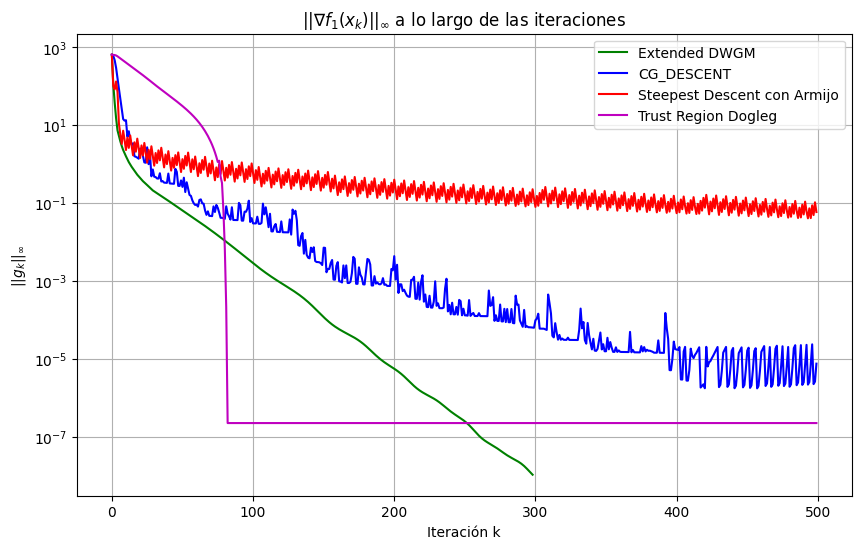

In [63]:
fig = plt.figure(figsize=(10, 6))
plt.plot(k_extDWGM, gk_norm_extDWGM, color = 'g', label = 'Extended DWGM')
plt.plot(k_cg_list, gk_cg_norm_list, color = 'b', label = 'CG_DESCENT')
plt.plot(k_steep_list[:500], gk_steep_norm_list[:500], color = 'r', label = 'Steepest Descent con Armijo')
plt.plot(k_tr_list, gk_tr_norm_list, color = 'm', label = 'Trust Region Dogleg')
plt.yscale('log')
plt.xlabel('Iteración k')
plt.ylabel(r'$||g_k||_{\infty}$')
plt.title(r'$|| \nabla f_1(x_k)||_{\infty}$ a lo largo de las iteraciones')
plt.legend()
plt.grid()
plt.show()

# Experimento 3

In [64]:
epsilon = 1e-8
n = 1000 
x0 = np.array([2.0]*n, dtype=np.float64)
history_extDWGM, dur_extDWGM = extended_DWGM(f2_func ,grad2_func, hessian2_func , ek_func , x0, t = 1 ,max_iter = 10000, epsilon = epsilon,delta = 0.9 ,gamma = 1e-4, m = 100)
k_extDWGM = history_extDWGM['iter']
fk_extDWGM = history_extDWGM['f']
gk_norm_extDWGM = history_extDWGM['g_norm']

Convergencia alcanzada tras 2 iteraciones


In [65]:
# Resultados con CG no lineal
history_cg, dur_cg = cg_descent(f2_func, grad2_func, x0, tol=epsilon, max_iter=500)
k_cg_list = history_cg['iter']
fk_cg_list = history_cg['f']
gk_cg_norm_list = history_cg['g_norm']

CG_DESCENT convergió en 7 iteraciones.


In [66]:
# Resultados con steepest descent con Armijo
history_sd, dur_sd = desc_grad_armijo(f2_func, grad2_func, x0, alpha_0=1.0, rho=0.5, c1=1e-4, max_it_GD=10000, tol_GD=epsilon, max_it_Armijo=100)
k_steep_list = history_sd['iter']
fk_steep_list = history_sd['f']
gk_steep_norm_list = history_sd['g_norm']

Maximo de iteraciones alcanzadas.


In [67]:
# Resultados con trust region dogleg
history_tr, dur_tr = trust_region_dogleg(f2_func, grad2_func, hessian2_func, x0, r_hat=1.0, r_0=0.1, eta=0.33, max_it=500, tol=epsilon)
k_tr_list = history_tr['iter']
fk_tr_list = history_tr['f']
gk_tr_norm_list = history_tr['g_norm']

Se alcanzo la convergencia tras 50 iteraciones.


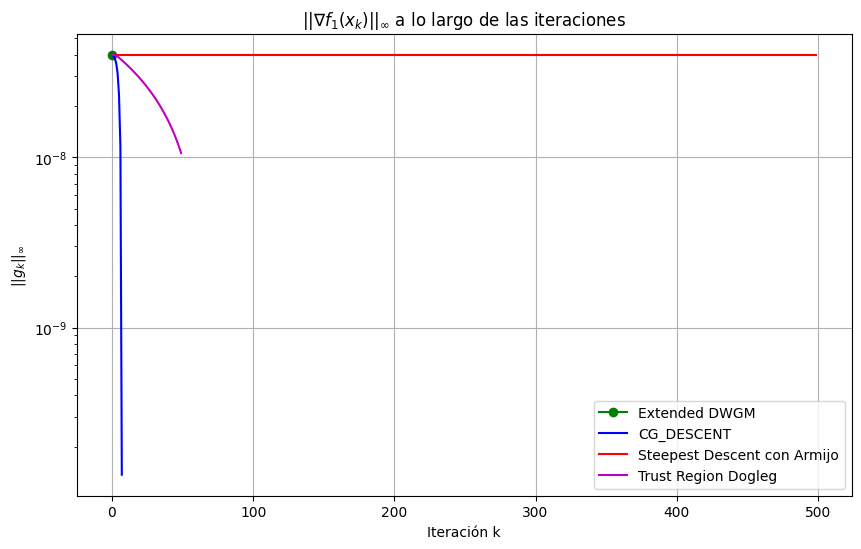

In [71]:
fig = plt.figure(figsize=(10, 6))
plt.plot(k_extDWGM, gk_norm_extDWGM,marker = 'o' ,color = 'g', label = 'Extended DWGM')
plt.plot(k_cg_list, gk_cg_norm_list, color = 'b', label = 'CG_DESCENT')
plt.plot(k_steep_list[:500], gk_steep_norm_list[:500], color = 'r', label = 'Steepest Descent con Armijo')
plt.plot(k_tr_list, gk_tr_norm_list, color = 'm', label = 'Trust Region Dogleg')
plt.yscale('log')
plt.xlabel('Iteración k')
plt.ylabel(r'$||g_k||_{\infty}$')
plt.title(r'$|| \nabla f_1(x_k)||_{\infty}$ a lo largo de las iteraciones')
plt.legend()
plt.grid()
plt.show()

## Experimento 4

In [95]:
# importar los datos de ionosphere
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
ionosphere = fetch_ucirepo(id=52) 
  
# data (as pandas dataframes) 
Z = ionosphere.data.features # matriz de caracteristicas, normalizada entre -1 y 1
y = ionosphere.data.targets  # etiquetas g: good, b: bad
  
# metadata 
print(ionosphere.metadata) 
  
# variable information 
print(ionosphere.variables) 


{'uci_id': 52, 'name': 'Ionosphere', 'repository_url': 'https://archive.ics.uci.edu/dataset/52/ionosphere', 'data_url': 'https://archive.ics.uci.edu/static/public/52/data.csv', 'abstract': 'Classification of radar returns from the ionosphere', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 351, 'num_features': 34, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Sun Jan 01 1989', 'dataset_doi': '10.24432/C5W01B', 'creators': ['V. Sigillito', 'S. Wing', 'L. Hutton', 'K. Baker'], 'intro_paper': None, 'additional_info': {'summary': 'This radar data was collected by a system in Goose Bay, Labrador.  This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts.  See the paper for more details.  

In [96]:
Z.values

array([[ 1.     ,  0.     ,  0.99539, ..., -0.54487,  0.18641, -0.453  ],
       [ 1.     ,  0.     ,  1.     , ..., -0.06288, -0.13738, -0.02447],
       [ 1.     ,  0.     ,  1.     , ..., -0.2418 ,  0.56045, -0.38238],
       ...,
       [ 1.     ,  0.     ,  0.94701, ...,  0.00442,  0.92697, -0.00577],
       [ 1.     ,  0.     ,  0.90608, ..., -0.03757,  0.87403, -0.16243],
       [ 1.     ,  0.     ,  0.8471 , ..., -0.06678,  0.85764, -0.06151]],
      shape=(351, 34))

In [97]:
y.values

array([['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
       ['b'],
       ['g'],
      

In [98]:
import pandas as pd

Z = Z.to_numpy()
y_mapped = y.iloc[:, 0].map({'g': 1, 'b': -1})
y = y_mapped.to_numpy()

In [102]:
def extended_DWGM(f_func ,grad_func, hessian_prod_func , ek_func, x0, t = 1 ,max_iter = 10000, epsilon = 1e-6,delta = 0.9 ,gamma = 1e-4, m = 100):
    
    """Implementación del algoritmo Extended DWGM del paper 'An extended delayed weighted gradient algorithm for solving strongly convex optimization problems' de R.Andreani, H. Oviedo, M.Raydan y L.D. Secchin
    
    Recibe:

    f_func : función objetivo a minimizar
    grad_func : función que devuelve el gradiente de f_func
    hessian_func : función que devuelve la Hessiana de f_func
    ek_func : función que devuelve el valor de ek para cada iteración k
    x0 : punto inicial para la optimización
    t : parámetro requerido para el algoritmo (default = 1)
    max_iter : número máximo de iteraciones para extended DWGM(default = 10000)
    epsilon : criterio de convergencia para extended DWGM (default = 1e-6)
    delta : parámetro requerido para el backtracking (default = 0.9)
    gamma : parámetro requerido para el backtracking (default = 1e-4)
    m : número máximo de iteraciones para el backtracking (default = 100)

    """
    x_k = x0.copy()
    g_k = grad_func(x_k)

    x_prev = x0.copy()
    g_prev = g_k.copy()
    
    gk_norm = np.linalg.norm(g_k)

    #listas para guardar la información de cada iteración
    history = {'iter': [], 'x': [], 'f': [], 'g_norm': []}
    start_convergence_time=time.perf_counter()


    for k in range(max_iter):

        gk_norm_inf = np.linalg.norm(g_k, ord=np.inf)

        if (gk_norm_inf <= epsilon):
            print(f"Convergencia alcanzada tras {k+1} iteraciones")
            break

        #Almacenamos la información de cada iteración
        history['iter'].append(k)
        history['x'].append(x_k.copy())
        history['f'].append(f_func(x_k))
        history['g_norm'].append(gk_norm_inf)
        
    
        #Paso 2 del algoritmo 1, página 3.
        w_k = hessian_prod_func(grad3_func,x_k,g_k)
        gk_T_wk = np.dot(g_k,w_k)

        #Inicialización de alpha_k como ec. 2a (paso 3)
        alpha_k =  gk_T_wk / np.dot(w_k,w_k)
        #Paso 4
        z_k = x_k - t* alpha_k *g_k
        #Paso 5 -> GRAD(ZK) = G_K - ALPHA*WK
        #r_k = g_k - alpha_k * w_k
        r_k = grad_func(z_k)
        # Backtracking (lineas 6-9 del algoritmo 1.)
        rk_norm = np.linalg.norm(r_k)
        for i in range(m):
            if (rk_norm**2 <= (gk_norm**2 - (gamma*t*alpha_k) * gk_T_wk)):
                break
            alpha_k = delta * alpha_k
            z_k = x_k - (t * alpha_k * g_k)
            r_k = grad_func(z_k)
            rk_norm = np.linalg.norm(r_k)
            
        # Calculo de beta_k, lineas 10-11 del algoritmo 1.
        y_k = r_k - g_prev
        beta_k = - np.dot(g_prev,y_k)/np.dot(y_k,y_k)

        # actualización de x_{k+1} con paso retrasado, linea 12 del algoritmo 1.
        x_next = x_prev + beta_k*(z_k - x_prev)
        g_next = grad_func(x_next)

        g_next_norm = np.linalg.norm(g_next)
        cond2 = rk_norm**2 + min (ek_func(k, gamma, t, alpha_k, gk_T_wk), gamma * t * alpha_k * gk_T_wk)
        if  g_next_norm**2 > cond2:
            x_next = z_k
            g_next = r_k
            g_next_norm = np.linalg.norm(g_next)
        
        # Actualización de variables para la siguiente iteración
        x_prev, x_k = x_k, x_next
        g_prev, g_k = g_k, g_next
        gk_norm = g_next_norm

    end_convergence_time = time.perf_counter()
    convergence_time = end_convergence_time - start_convergence_time
    return history, convergence_time
    

In [116]:
n = Z.shape[1]  # Número de características
epsilon = 1e-8
sigma = 0.0
x0 = np.array([1.0]*n, dtype=np.float64)
history_extDWGM, dur_extDWGM = extended_DWGM(lambda x: f3_func(x, Z, y,sigma), lambda x: grad3_func(x, Z, y, sigma), lambda grad3_func,x, gk: get_hessian_vector_product(grad3_func, x, gk, Z, y, sigma), ek_func, x0, t = 1, max_iter = 10000, epsilon = epsilon, delta = 0.9, gamma = 1e-4, m = 100)
k_extDWGM = history_extDWGM['iter']
fk_extDWGM = history_extDWGM['f']
gk_norm_extDWGM = history_extDWGM['g_norm']

Convergencia alcanzada tras 161 iteraciones


In [117]:
# Resultados con CG no lineal
history_cg, dur_cg = cg_descent(lambda x: f3_func(x, Z, y,sigma), lambda x: grad3_func(x, Z, y, sigma), x0, tol=epsilon, max_iter=500)
k_cg_list = history_cg['iter']
fk_cg_list = history_cg['f']
gk_cg_norm_list = history_cg['g_norm']

In [118]:
# Resultados con steepest descent con Armijo
history_sd, dur_sd = desc_grad_armijo(lambda x: f3_func(x, Z, y,sigma), lambda x: grad3_func(x, Z, y, sigma), x0, alpha_0=1.0, rho=0.5, c1=1e-4, max_it_GD=10000, tol_GD=epsilon, max_it_Armijo=100)
k_steep_list = history_sd['iter']
fk_steep_list = history_sd['f']
gk_steep_norm_list = history_sd['g_norm']

Maximo de iteraciones alcanzadas.


In [123]:
# Resultados con trust region dogleg
history_tr, dur_tr = trust_region_dogleg(lambda x: f3_func(x, Z, y,sigma), lambda x: grad3_func(x, Z, y, sigma), lambda x: hessian3_func(x, Z, y, sigma), x0, r_hat=1.0, r_0=0.1, eta=0.33, max_it=500, tol=epsilon)
k_tr_list = history_tr['iter']
fk_tr_list = history_tr['f']
gk_tr_norm_list = history_tr['g_norm']

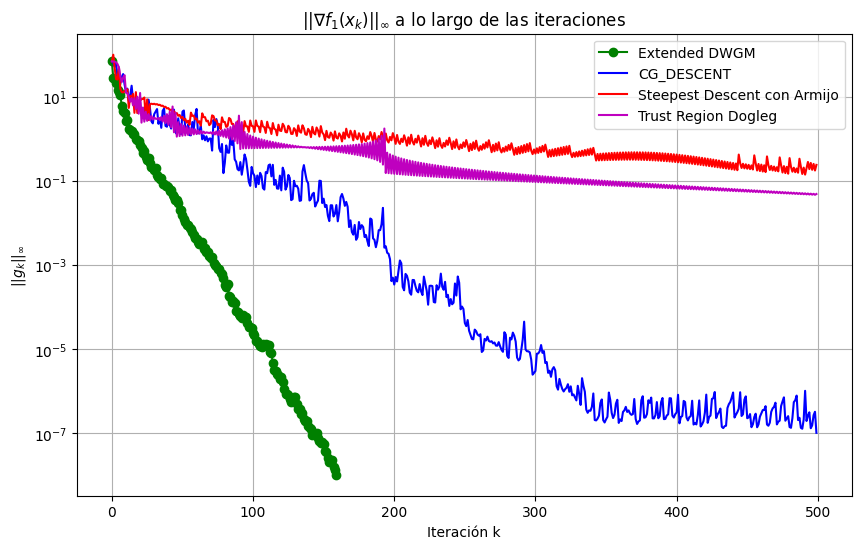

In [124]:
fig = plt.figure(figsize=(10, 6))
plt.plot(k_extDWGM, gk_norm_extDWGM,marker = 'o' ,color = 'g', label = 'Extended DWGM')
plt.plot(k_cg_list, gk_cg_norm_list, color = 'b', label = 'CG_DESCENT')
plt.plot(k_steep_list[:500], gk_steep_norm_list[:500], color = 'r', label = 'Steepest Descent con Armijo')
plt.plot(k_tr_list, gk_tr_norm_list, color = 'm', label = 'Trust Region Dogleg')
plt.yscale('log')
plt.xlabel('Iteración k')
plt.ylabel(r'$||g_k||_{\infty}$')
plt.title(r'$|| \nabla f_1(x_k)||_{\infty}$ a lo largo de las iteraciones')
plt.legend()
plt.grid()
plt.show()